<a href="https://colab.research.google.com/github/sholihin999/praktikumml/blob/main/praktikum13mandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Library

In [1]:
!pip install kaggle

In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
Kaggle = '/content/kaggle.json'

In [4]:
!mkdir -p ~/.kaggle
!cp {Kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#Load dataset

In [5]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
 37% 25.0M/66.7M [00:00<00:00, 257MB/s]
100% 66.7M/66.7M [00:00<00:00, 373MB/s]


In [6]:
from zipfile import ZipFile
import os
file_name = '/content/handwritten-digits-0-9.zip'

extract_folder = 'dataset'
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')


Done


In [7]:
import os

data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [8]:
len(data_0)

2236

In [9]:
data = []
labels = []

base_path = '/content/dataset/'

for label in range(10):
  folder_path = os.path.join(base_path,str(label))

  for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path,image_name)

    img = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img,(28, 28))

    img = img / 255.0

    img = img.flatten()

    data.append(img)
    labels.append(label)

X = np.array(data)
y = np.array(labels)
print("Shape x:", X.shape)
print("Shape y:", y.shape)

Shape x: (21555, 784)
Shape y: (21555,)


#Visualisasi Sampel Data

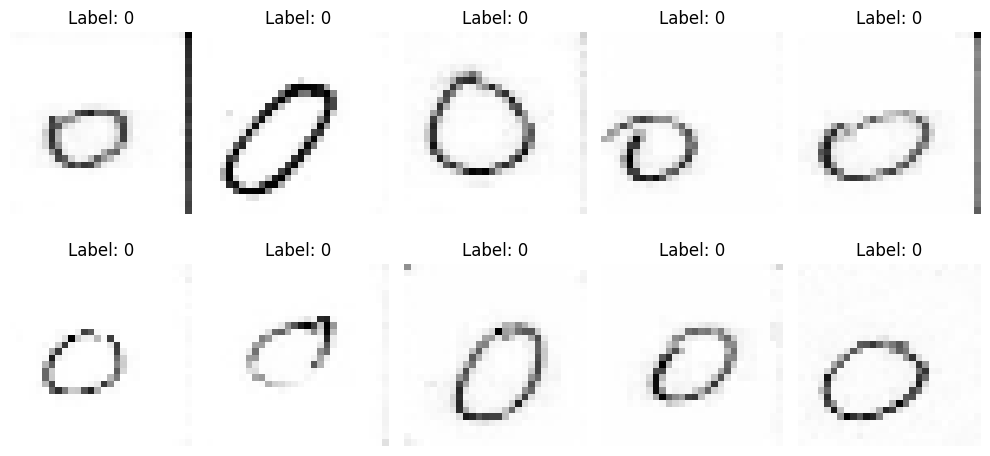

In [10]:

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {y[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()


#Spliting dan Encoding

In [11]:
# Split Data Training dan Testing (80:20)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#One-Hot Encoding pada Label
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [12]:
print("X_train dtype:", X_train.dtype, "shape:", X_train.shape)
print("X_test  dtype:", X_test.dtype,  "shape:", X_test.shape)
print("y_train dtype:", y_train.dtype, "shape:", y_train.shape)
print("y_test  dtype:", y_test.dtype,  "shape:", y_test.shape)

X_train dtype: float64 shape: (17244, 784)
X_test  dtype: float64 shape: (4311, 784)
y_train dtype: float64 shape: (17244, 10)
y_test  dtype: float64 shape: (4311, 10)


In [13]:
input_shape = X_train.shape[1]
print("input_shape:", input_shape)

input_shape: 784


#Pembuatan Model ANN (MLP)

In [14]:
model = Sequential()

# Hidden layer 1
model.add(Dense(256, activation='relu', input_dim=X_train.shape[1]))

# Hidden layer 2
model.add(Dense(128, activation='relu'))

# Hidden layer 3
model.add(Dense(64, activation='relu'))

# Output layer (10 kelas untuk digit 0-9)
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Kompilasi Model

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

#Early Stopping

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#Training Model

In [17]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1051 - loss: 2.3301 - val_accuracy: 0.1763 - val_loss: 2.2309
Epoch 2/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1824 - loss: 2.1973 - val_accuracy: 0.2259 - val_loss: 2.0932
Epoch 3/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2542 - loss: 2.0359 - val_accuracy: 0.2607 - val_loss: 2.0446
Epoch 4/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2845 - loss: 1.9634 - val_accuracy: 0.3453 - val_loss: 1.8580
Epoch 5/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3351 - loss: 1.8653 - val_accuracy: 0.4085 - val_loss: 1.7371
Epoch 6/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3578 - loss: 1.8016 - val_accuracy: 0.3911 - val_loss: 1.7359
Epoch 7/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3800 - loss: 1.7526 - val_accuracy: 0.3624 - val_loss: 1.8105
Epoch 8/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4074 - loss: 1.6904 - val_accu

#Evaluasi Model

In [18]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)
print("Test Loss:", loss)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7303 - loss: 0.7978
Test Accuracy: 0.7323126792907715
Test Loss: 0.8030855059623718


#Visualisasi Hasil Pelatihan (Accuracy dan Loss)

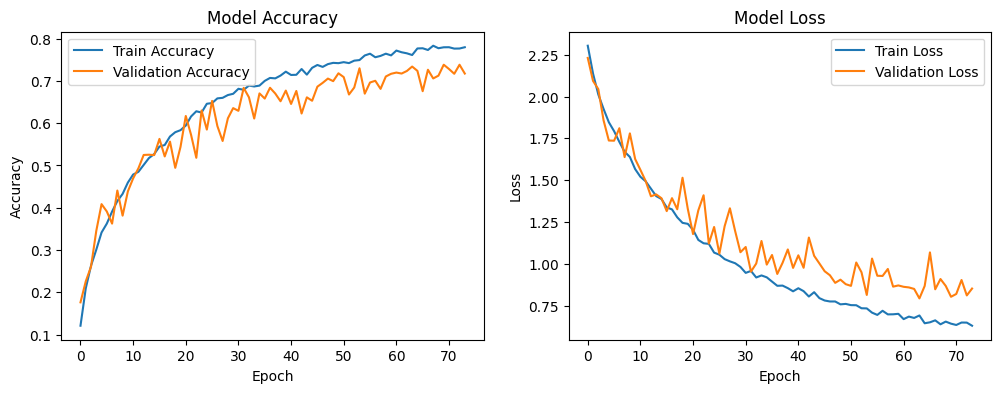

In [19]:
plt.figure(figsize=(12,4))

# Grafik Model Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Model Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()